In [3]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [ ]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

In [6]:
from IPython import get_ipython
ipython = get_ipython()
if ipython is not None:
    try:
        ipython.magic(u'matplotlib inline')
    except AttributeError:
        ipython.run_line_magic('matplotlib', 'inline')

import matplotlib.pyplot as plt
import numpy as np
import os
import urllib
from astropy import constants as c

#from disklab import opacity
import dsharp_opac as opacity

# import aux_functions as aux
# aux.set_style()

if not os.path.isdir('figures'):
    os.mkdir('figures')

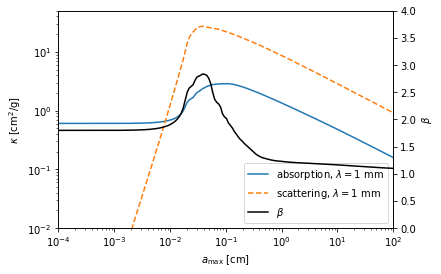

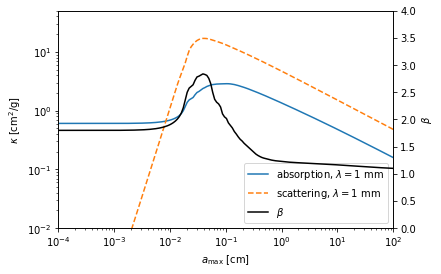

In [14]:

d      = np.load(opacity.get_datafile('default_opacities_smooth.npz'))
a      = d['a']
lam    = d['lam']
k_abs  = d['k_abs']
k_sca  = d['k_sca']
gsca   = d['g']

k_sca_eff = (1 - gsca) * k_sca
eps_nu = k_abs / (k_abs + k_sca_eff)

lam_avg = [0.1, 0.3]
q       = [3.5]
res     = [opacity.size_average_opacity(lam_avg, a, lam, k_abs, k_sca, q=_q, plot=True) for _q in q]
res_eff = [opacity.size_average_opacity(lam_avg, a, lam, k_abs, k_sca_eff, q=_q, plot=True) for _q in q]

eps_eff = [_res_eff['ka'] / (_res_eff['ka'] + _res_eff['ks']) for _res_eff in res_eff]

In [11]:
print(f'a: min:{min(a)}, max: {max(a)}, length: {len(a)}')
print(f'a: min:{min(lam)}, max: {max(lam)}, length: {len(lam)}')

a: min:1e-05, max: 100.0, length: 200
a: min:1e-05, max: 10.0, length: 210


In [19]:
# Calculate the Mie opacities, this takes *very* long if `extrapolate_large_grains=False`.

res_def = opacity.get_opacities(a, lam, rho_s=rhos_default, diel_const=d_def, extrapol=True, extrapolate_large_grains=True)

NameError: name 'rhos_default' is not defined

In [18]:

lam_avg =[0.1, 0.3]

r_def = opacity.size_average_opacity(lam_avg, a, lam, res_def['k_abs'], res_def['k_sca'], plot=False)
r_por = opacity.size_average_opacity(lam_avg, a, lam, res_por['k_abs'], res_por['k_sca'], plot=False)
r_h2o = opacity.size_average_opacity(lam_avg, a, lam, res_h2o['k_abs'], res_h2o['k_sca'], plot=False)
r_c01 = opacity.size_average_opacity(lam_avg, a, lam, res_c01['k_abs'], res_c01['k_sca'], plot=False)
r_c02 = opacity.size_average_opacity(lam_avg, a, lam, res_c02['k_abs'], res_c02['k_sca'], plot=False)
#r_c03 = opacity.size_average_opacity(lam_avg, a, lam, res_c03['k_abs'], res_c03['k_sca'], plot=False)
#r_c04 = opacity.size_average_opacity(lam_avg, a, lam, res_c04['k_abs'], res_c04['k_sca'], plot=False)
#r_c05 = opacity.size_average_opacity(lam_avg, a, lam, res_c05['k_abs'], res_c05['k_sca'], plot=False)
r_c06 = opacity.size_average_opacity(lam_avg, a, lam, res_c06['k_abs'], res_c06['k_sca'], plot=False)

NameError: name 'res_def' is not defined

In [16]:
names     = ['default']# 'porous', 'high-water', 'Jäger', 'Zubko', r'Draine ($a=0.10, \bot$)']
r_array   = [r_def,  ]#   r_por,    r_h2o,        r_c01,   r_c02,   r_c06]
res_array = [res_def, ]#  res_por,  res_h2o,      res_c01, res_c02, res_c06]
eps_array = [eps_def, ]#  eps_por,  eps_h2o,      eps_c01, eps_c02, eps_c06]

NameError: name 'r_def' is not defined

using amax = 1.0234114021054528 mm


NameError: name 'res_array' is not defined

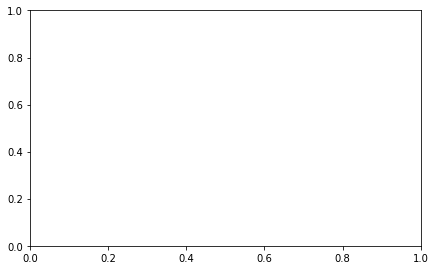

In [17]:

# make a size distribution up to 1 mm

s        = a**0.5
ia       = np.abs(a - 0.1).argmin()
s[ia+1:] = 0.
s        = s / s.sum()

print('using amax = {} mm'.format(a[np.where(s > 0)[0][-1]] * 10))

f, ax = plt.subplots(figsize=(7, 7 / 1.68 * 1.039))

for res, name in zip(res_array, names):

    # average the opacities with that size distribution

    k_a_avg = (res['k_abs'].T * s).sum(1)

    ax.loglog(lam, k_a_avg, label=name)
    
# other opacities
ax.loglog(la * 1e-4, ka, 'k--', zorder=-100, label='Andrews et al. 2009')
ax.loglog(lam,       kb, 'k--', zorder=-100, alpha=0.5, label='Beckwith et al. 1990')
    
# format the plot
    
ax.legend(fontsize='small', loc=3, ncol=2)

ax.set_xlim(1e-5, 1e0)
ax.set_ylim(1e-2, 2e3)

ax.set_xlabel(r'$\lambda$ [cm]')
ax.set_ylabel(r'$\kappa_\nu^\mathrm{abs,tot}$ [cm$^2$/g]')

f.subplots_adjust(
    left=0.09, right=0.97,
    bottom=0.1, top=0.98,
    wspace=0.1, hspace=0.05)